In [146]:
from bs4 import BeautifulSoup
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import re

In [147]:
import os

for root, dirs, files in os.walk('/kaggle/input'):
    for file in files:
        print(os.path.join(root, file))

/kaggle/input/datasets/sttupina/university-sites/hse.html
/kaggle/input/datasets/sttupina/university-sites/mipt.html
/kaggle/input/datasets/sttupina/university-sites/itmo.html
/kaggle/input/datasets/sttupina/university-sites/mai.html


In [148]:
html_files = {
    "МАИ": "/kaggle/input/datasets/sttupina/university-sites/mai.html",
    "МФТИ": "/kaggle/input/datasets/sttupina/university-sites/mipt.html",
    "ВШЭ": "/kaggle/input/datasets/sttupina/university-sites/hse.html",
    "ИТМО": "/kaggle/input/datasets/sttupina/university-sites/itmo.html"
}

In [149]:
targets = {
    "Правила приема": [
        "правила приема", "правила приёма"
    ],
    "Программы": [
        "образовательные программы", "программы обучения",
        "направления подготовки", "выбрать программу"
    ],
    "Конкурсные списки": [
        "конкурсные списки", "рейтинговые списки", "списки поступающих"
    ],
    "Подача документов": [
        "подать документы", "подать заявление", "личный кабинет"
    ],
    "Стоимость": [
        "стоимость обучения", "платное обучение"
    ],
    "Иностранные абитуриенты": [
        "иностранным гражданам", "иностранные граждане", "foreign applicants"
    ],
    "Контакты приемной комиссии": [
        "приемная комиссия", "приёмная комиссия", "контакты"
    ]
}

In [150]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r"\s+", " ", text)
    return text.strip()

In [151]:
def analyze_navigation(university, filepath):
    with open(filepath, "r", encoding="utf-8", errors="ignore") as file:
        html = file.read()

    soup = BeautifulSoup(html, "html.parser")

    for tag in soup(["script", "style", "noscript", "svg"]):
        tag.decompose()

    page_text = clean_text(soup.get_text(" ", strip=True))

    links = soup.find_all("a", href=True)
    buttons = soup.find_all("button")

    link_texts = [
        clean_text(a.get_text(" ", strip=True))
        for a in links
        if clean_text(a.get_text(" ", strip=True))
    ]

    button_texts = [
        clean_text(button.get_text(" ", strip=True))
        for button in buttons
        if clean_text(button.get_text(" ", strip=True))
    ]

    result = {
        "Вуз": university,
        "Слов на странице": len(page_text.split()),
        "Ссылок": len(links),
        "Кнопок": len(buttons),
        "Текстовых ссылок": len(link_texts),
        "Текстовых кнопок": len(button_texts)
    }

    for target, keywords in targets.items():

        found_on_page = any(
            keyword in page_text
            for keyword in keywords
        )

        found_in_links = any(
            any(keyword in link_text for keyword in keywords)
            for link_text in link_texts
        )

        found_in_buttons = any(
            any(keyword in button_text for keyword in keywords)
            for button_text in button_texts
        )

        result[f"{target}: есть на странице"] = int(found_on_page)
        result[f"{target}: есть в ссылках"] = int(found_in_links)
        result[f"{target}: есть в кнопках"] = int(found_in_buttons)

    return result

In [152]:
benchmark_df = pd.DataFrame([
    analyze_navigation(university, filepath)
    for university, filepath in html_files.items()
])

benchmark_df

,Вуз,Слов на странице,Ссылок,Кнопок,Текстовых ссылок,Текстовых кнопок,Правила приема: есть на странице,Правила приема: есть в ссылках,Правила приема: есть в кнопках,Программы: есть на странице,...,Подача документов: есть в кнопках,Стоимость: есть на странице,Стоимость: есть в ссылках,Стоимость: есть в кнопках,Иностранные абитуриенты: есть на странице,Иностранные абитуриенты: есть в ссылках,Иностранные абитуриенты: есть в кнопках,Контакты приемной комиссии: есть на странице,Контакты приемной комиссии: есть в ссылках,Контакты приемной комиссии: есть в кнопках
0,МАИ,1327,384,74,353,8,1,1,0,1,...,0,1,1,0,1,1,1,1,1,0
1,МФТИ,328,60,2,53,2,1,1,0,1,...,0,1,1,0,0,0,0,1,1,0
2,ВШЭ,2685,569,15,566,6,1,1,0,1,...,0,1,1,0,1,1,0,1,1,0
3,ИТМО,2896,130,30,124,29,1,1,0,1,...,1,0,0,0,0,0,0,1,1,0


In [153]:
page_cols = [
    f"{target}: есть на странице"
    for target in targets.keys()
]

link_cols = [
    f"{target}: есть в ссылках"
    for target in targets.keys()
]

button_cols = [
    f"{target}: есть в кнопках"
    for target in targets.keys()
]

benchmark_df["Информационная полнота"] = benchmark_df[page_cols].sum(axis=1)

benchmark_df["Навигационная доступность"] = benchmark_df[link_cols].sum(axis=1)

benchmark_df["Целевые действия"] = benchmark_df[button_cols].sum(axis=1)

benchmark_df["Индекс перегруженности"] = (
    benchmark_df["Слов на странице"] / benchmark_df["Слов на странице"].max()
    + benchmark_df["Ссылок"] / benchmark_df["Ссылок"].max()
)

benchmark_df["Информационная плотность"] = (
    benchmark_df["Слов на странице"]
    /
    (
        benchmark_df["Ссылок"] +
        benchmark_df["Кнопок"]
    )
)

In [154]:
benchmark_df["Итоговый UX-score"] = (
    benchmark_df["Информационная полнота"] * 0.2
    + benchmark_df["Навигационная доступность"] * 0.5
    + benchmark_df["Целевые действия"] * 0.3
    - benchmark_df["Индекс перегруженности"] * 0.7
)

benchmark_df.sort_values("Итоговый UX-score", ascending=False)

,Вуз,Слов на странице,Ссылок,Кнопок,Текстовых ссылок,Текстовых кнопок,Правила приема: есть на странице,Правила приема: есть в ссылках,Правила приема: есть в кнопках,Программы: есть на странице,...,Иностранные абитуриенты: есть в кнопках,Контакты приемной комиссии: есть на странице,Контакты приемной комиссии: есть в ссылках,Контакты приемной комиссии: есть в кнопках,Информационная полнота,Навигационная доступность,Целевые действия,Индекс перегруженности,Информационная плотность,Итоговый UX-score
0,МАИ,1327,384,74,353,8,1,1,0,1,...,1,1,1,0,6,6,1,1.133086,2.897380,3.706840
1,МФТИ,328,60,2,53,2,1,1,0,1,...,0,1,1,0,4,4,0,0.218708,5.290323,2.646905
3,ИТМО,2896,130,30,124,29,1,1,0,1,...,0,1,1,0,4,4,1,1.228471,18.100000,2.240070
2,ВШЭ,2685,569,15,566,6,1,1,0,1,...,0,1,1,0,6,4,0,1.927141,4.597603,1.851001


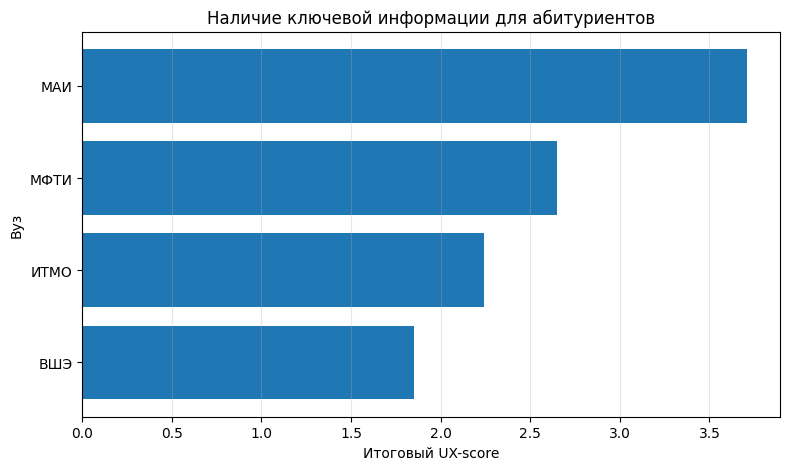

In [155]:
plot_df = benchmark_df.sort_values("Итоговый UX-score", ascending=True)

plt.figure(figsize=(9, 5))

plt.barh(
    plot_df["Вуз"],
    plot_df["Итоговый UX-score"]
)

plt.title("Наличие ключевой информации для абитуриентов")
plt.xlabel("Итоговый UX-score")
plt.ylabel("Вуз")

plt.grid(axis="x", alpha=0.3)

plt.show()

In [156]:
benchmark_df[
    [
        "Вуз",
        "Информационная полнота",
        "Навигационная доступность",
        "Целевые действия",
        "Индекс перегруженности",
        "Итоговый UX-score",
        "Слов на странице",
        "Ссылок",
        "Кнопок"
    ]
].sort_values("Итоговый UX-score", ascending=False)

,Вуз,Информационная полнота,Навигационная доступность,Целевые действия,Индекс перегруженности,Итоговый UX-score,Слов на странице,Ссылок,Кнопок
0,МАИ,6,6,1,1.133086,3.706840,1327,384,74
1,МФТИ,4,4,0,0.218708,2.646905,328,60,2
3,ИТМО,4,4,1,1.228471,2.240070,2896,130,30
2,ВШЭ,6,4,0,1.927141,1.851001,2685,569,15


In [157]:
benchmark_df["Ссылок на 1000 слов"] = (
    benchmark_df["Ссылок"]
    /
    benchmark_df["Слов на странице"]
) * 1000

benchmark_df["Кнопок на 1000 слов"] = (
    benchmark_df["Кнопок"]
    /
    benchmark_df["Слов на странице"]
) * 1000

In [158]:
benchmark_df[
    [
        "Вуз",
        "Слов на странице",
        "Ссылок",
        "Кнопок",
        "Ссылок на 1000 слов",
        "Кнопок на 1000 слов"
    ]
]

,Вуз,Слов на странице,Ссылок,Кнопок,Ссылок на 1000 слов,Кнопок на 1000 слов
0,МАИ,1327,384,74,289.374529,55.764883
1,МФТИ,328,60,2,182.926829,6.097561
2,ВШЭ,2685,569,15,211.918063,5.586592
3,ИТМО,2896,130,30,44.889503,10.359116


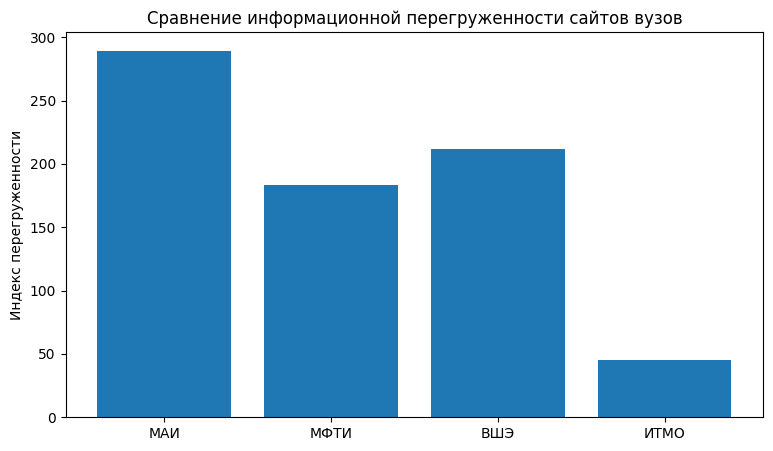

In [159]:
plt.figure(figsize=(9,5))

plt.bar(
    benchmark_df["Вуз"],
    benchmark_df["Ссылок на 1000 слов"]
)

plt.title("Сравнение информационной перегруженности сайтов вузов")

plt.ylabel("Индекс перегруженности")

plt.show()

In [160]:
benchmark_df["Избыточность навигации"] = (
    benchmark_df["Ссылок"] + benchmark_df["Кнопок"]
)

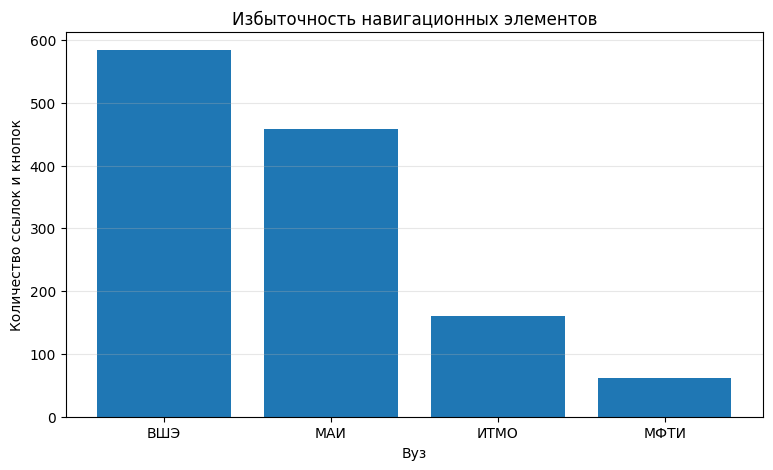

In [161]:
plot_df = benchmark_df.sort_values(
    "Избыточность навигации",
    ascending=False
)

plt.figure(figsize=(9,5))

plt.bar(
    plot_df["Вуз"],
    plot_df["Избыточность навигации"]
)

plt.title("Избыточность навигационных элементов")
plt.xlabel("Вуз")
plt.ylabel("Количество ссылок и кнопок")

plt.grid(axis="y", alpha=0.3)

plt.show()

## Вывод по сравнительному анализу

На первом уровне сравнения сайт МАИ демонстрирует высокие значения по количественным показателям: на странице присутствует большой объем информации, большое количество ссылок и основные разделы, необходимые абитуриенту.

Однако более детальный анализ показывает, что высокие значения связаны не с лучшей организацией интерфейса, а с информационной перегруженностью страницы. Большое количество ссылок и текстовых блоков увеличивает сложность выбора следующего действия для пользователя.

Таким образом, проблема сайта МАИ заключается не в отсутствии информации, а в ее структуре и способе представления. Это согласуется с результатами анализа Яндекс.Метрики: пользователи сталкиваются с трудностями при прохождении сценария поступления, что выражается в отказах, низкой глубине просмотра и коротких сессиях на отдельных страницах.

Полученные результаты подтверждают необходимость реинжиниринга интерфейса: требуется не добавление новой информации, а переработка навигации, выделение ключевых действий и формирование понятного пошагового сценария для абитуриента.